Ensemble size: 5
u_hat_mean shape: (1000, 1000)


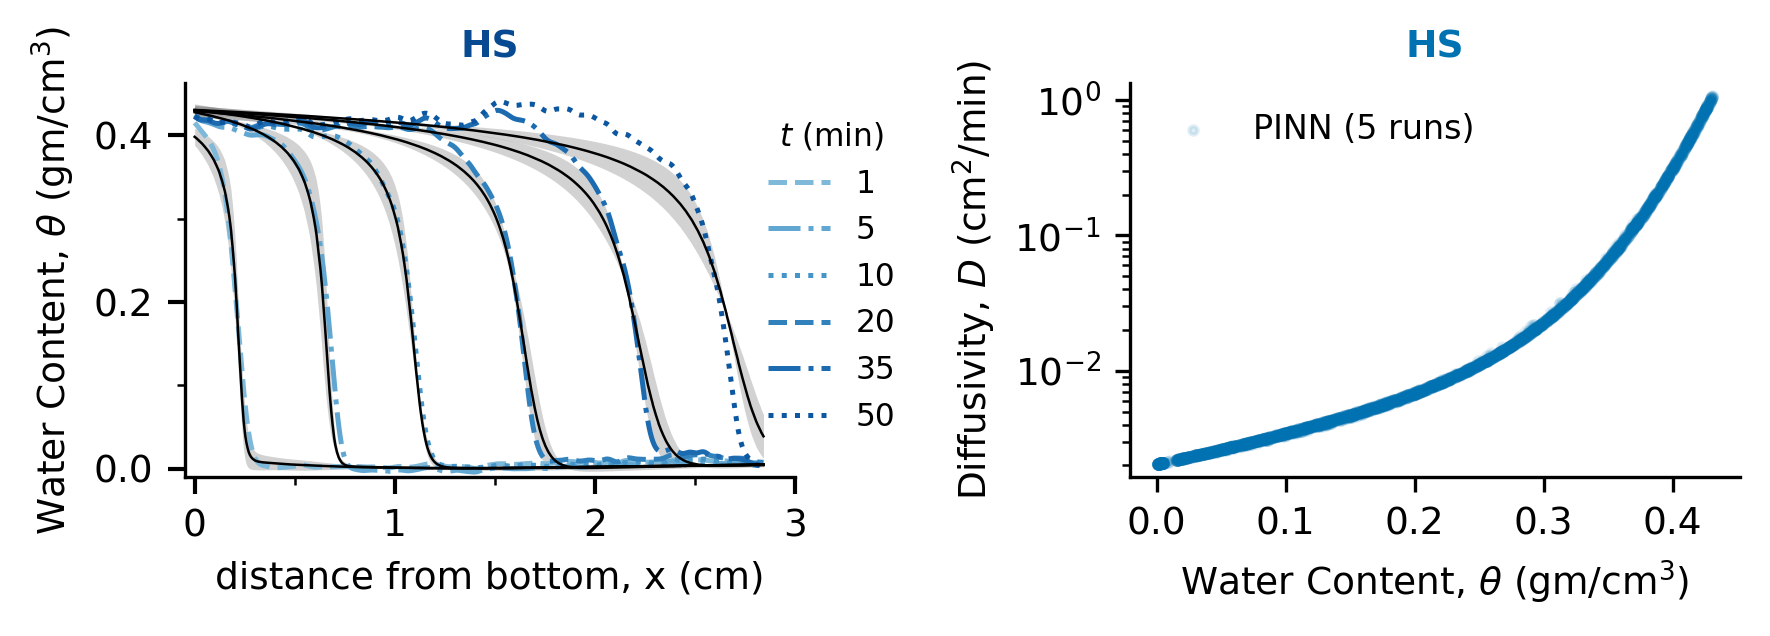

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import os

# ── paths ─────────────────────────────────────────────────────────────────────
best_dir  = "/home/idea-linux3/Sunav_main/Code_Diffusion_PINN/PINN_model/HS_outputs"
data_dir  = os.path.join(best_dir, "..", "..", "data")   # adjust if needed

# ── load completed runs ───────────────────────────────────────────────────────
n_runs = 5   # update this as more runs finish

u_hats = []
d_hats = []
for r in range(1, n_runs + 1):
    u_hats.append(np.load(os.path.join(best_dir, f"u_hat_{r}.npy")))
    d_hats.append(np.load(os.path.join(best_dir, f"d_hat_{r}.npy")))

u_hat_stack = np.stack(u_hats, axis=0)       # (n_runs, 1000, 1000)
d_hat_stack = np.stack(d_hats, axis=0)

u_hat_mean = u_hat_stack.mean(axis=0)        # (1000, 1000)
d_hat_mean = d_hat_stack.mean(axis=0)
u_hat_std  = u_hat_stack.std(axis=0)
d_hat_std  = d_hat_stack.std(axis=0)

print(f"Ensemble size: {n_runs}")
print(f"u_hat_mean shape: {u_hat_mean.shape}")

# ── load HS experimental data ─────────────────────────────────────────────────
HS_path   = os.path.join(data_dir)
HS_data   = np.load(os.path.join(HS_path, "HS_log_profiles.npy")) * -5.44366
HS_times  = np.round(np.load(os.path.join(HS_path, "HS_difference_times.npy")), 2)
HS_pixel  = 31.63                                      # um
HS_x      = np.arange(0, HS_data.shape[1]) * HS_pixel / 10000   # cm

HS_select_times = [1.5, 5, 10, 20, 35, 50]
HS_select_idx   = np.where(np.isin(HS_times, HS_select_times))[0]

HS_diffusion_scaling = 0.25 * np.max(HS_x)**2 / np.max(HS_times)

# ── PINN grid ─────────────────────────────────────────────────────────────────
x_pinn = np.linspace(0, np.max(HS_x),    1000)
t_pinn = np.linspace(0, np.max(HS_times), 1000)

def get_closest_indices(target_times, full_time_array):
    return np.array([np.argmin(np.abs(full_time_array - t)) for t in target_times])

pinn_idx = get_closest_indices(HS_select_times, t_pinn)

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.22), dpi=300)

linestyles = ["--", "-.", ":", "--", "-.", ":"]
colors_exp = plt.cm.Blues(np.linspace(0.45, 0.85, len(HS_select_times)))

# ── Panel 1: water content profiles ──────────────────────────────────────────
ax = axes[0]
for j, idx in enumerate(HS_select_idx):
    ax.plot(HS_x, HS_data[idx] * 0.805,
            color=colors_exp[j],
            linestyle=linestyles[j],
            linewidth=1.2,
            label=f"{int(HS_select_times[j])}")

for j, pidx in enumerate(pinn_idx):
    ax.plot(x_pinn, u_hat_mean[pidx, :],
            color='k', linestyle='-', linewidth=0.6)
    ax.fill_between(x_pinn,
                    u_hat_mean[pidx, :] - 2*u_hat_std[pidx, :],
                    u_hat_mean[pidx, :] + 2*u_hat_std[pidx, :],
                    color='grey', alpha=0.35, linewidth=0.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(-0.05, 3.0)
ax.set_ylim(-0.01, None)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.tick_params(axis="both", which="major", length=4, width=1, labelsize=9)
ax.set_xlabel("distance from bottom, x (cm)", fontsize=9)
ax.set_ylabel(r"Water Content, $\theta$ (gm/cm$^3$)", fontsize=9)
ax.set_title("HS", fontsize=9, fontweight="bold", color=plt.cm.Blues(0.9))
legend = ax.legend(loc="upper left", bbox_to_anchor=(0.91, 0.975),
                   fontsize=7.5, handlelength=2.0,
                   title=r"$t$ (min)", frameon=False)
plt.setp(legend.get_title(), fontsize=7.5)

# ── Panel 2: D(θ) scatter (data only) ────────────────────────────────────────
ax = axes[1]

flat_theta = u_hat_mean.flatten()
flat_D     = d_hat_mean.flatten() * HS_diffusion_scaling

sorted_idx   = np.argsort(flat_theta)
theta_sorted = flat_theta[sorted_idx]
D_sorted     = flat_D[sorted_idx]

# subsample for plotting speed
n_bins, samp = 30, 100
bin_edges = np.linspace(theta_sorted.min(), theta_sorted.max(), n_bins + 1)
theta_s, D_s = [], []
rng = np.random.default_rng(seed=42)
for k in range(n_bins):
    mask = (theta_sorted >= bin_edges[k]) & (theta_sorted < bin_edges[k+1])
    idx_bin = np.where(mask)[0]
    if len(idx_bin) == 0:
        continue
    chosen = rng.choice(idx_bin, size=min(samp, len(idx_bin)), replace=False)
    theta_s.extend(theta_sorted[chosen])
    D_s.extend(D_sorted[chosen])
theta_s = np.array(theta_s)
D_s     = np.array(D_s)

ax.scatter(theta_s, D_s, color='#0072B2', s=4, alpha=0.12,
           label=f"PINN ({n_runs} runs)")


ax.set_yscale('log')
ax.set_ylim(0.8*D_s.min(), 1.25*D_s.max())
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis='both', labelsize=9)
ax.set_xlabel(r"Water Content, $\theta$ (gm/cm$^3$)", fontsize=9)
ax.set_ylabel(r"Diffusivity, $D$ (cm$^2$/min)", fontsize=9)
ax.set_title("HS", fontsize=9, fontweight="bold", color='#0072B2')
ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()